# Project 4: Image Classification on CIFAR-10

## Part 2 of 4 — Model Building & Training

**Objective.** Part 1 (`01_Data_Exploration.ipynb`) established the facts: CIFAR-10 is perfectly
balanced across 10 classes, images are 32×32, and the normalization constants were *verified* from
the raw data rather than copied from other codebases. This notebook puts those facts to work. It
trains **three competing architectures** under one shared, deterministic training protocol — a small
CNN written from scratch, a transfer-learned EfficientNet-V2-S, and a paper-compliant
Wide ResNet-28-10 — evaluates them with identical metrics, diagnoses the winner with a confusion
matrix, and exports a single artifact that the remaining stages (GPU benchmarking, deployment)
consume without modification.

**What this notebook covers**

| Section | Question it answers |
| :-- | :-- |
| 1. Environment & Setup | What hardware/software is available and how is the run made reproducible? |
| 2. Data Loading & Augmentation | How is the data transformed and loaded for training? |
| 3. Training Protocol | What single recipe do all three models share? |
| 4. Model 1 — CNN from Scratch | Is a small hand-built baseline competitive? |
| 5. Model 2 — EfficientNet-V2-S | How much does transfer learning buy? |
| 6. Model 3 — Wide ResNet-28-10 | What does a from-scratch state-of-the-art model achieve? |
| 7. Model Comparison | Which model wins, and why? |
| 8. Error Analysis | Where does the best model still fail? |
| 9. Exporting the Final Model | Which artifact ships to Parts 3 & 4? |
| 10. Findings & Next Steps | What do the results mean for the rest of the pipeline? |

> **How to run:** execute the cells top to bottom. Run Part 1 first so that
> `../outputs/dataset_summary.json` (normalization constants, class names) is available — Part 2
> reads its preprocessing facts from that file instead of hard-coding them. Every figure, metric
> and checkpoint is exported to `../outputs/` and `../models/`. A GPU is strongly recommended; on
> the RTX 4060 used here the full notebook takes roughly 3.5 hours (the 50-epoch WRN-28-10 run
> dominates the wall clock).

## 1. Environment & Setup

All imports, reproducibility settings, and paths are centralized here. A fixed random seed,
CUDA benchmark mode, and deterministic data loading make every training run reproducible.

> **Windows note:** PyTorch and NumPy both ship a `libiomp5md.dll`, and the resulting OMP conflict
> can abort the kernel (`OMP: Error #15`). The `KMP_DUPLICATE_LIB_OK` flag below prevents this and
> must be set **before** importing PyTorch — it is harmless on other platforms.

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # required on Windows (see note above)

import json
import platform
import sys
import time
import urllib.error
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision import models

warnings.filterwarnings("ignore")


# -----------------------------------------------------------------------------
# Reproducibility
# -----------------------------------------------------------------------------
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True  # fastest conv algorithms for fixed input size

# -----------------------------------------------------------------------------
# Paths (relative to this notebook, which lives in notebooks/)
# -----------------------------------------------------------------------------
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "raw"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
PLOT_DIR = OUTPUT_DIR / "plots"
MODEL_DIR = PROJECT_ROOT / "models"

for dir_ in (OUTPUT_DIR, PLOT_DIR, MODEL_DIR):
    dir_.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# Shared project code (src/) - the single implementation of models & training
# -----------------------------------------------------------------------------
sys.path.insert(0, str(PROJECT_ROOT))
from src.data_loader import build_cifar10_loaders
from src.model_utils import SimpleCNN, WideResNet, build_efficientnet_v2_s
from src.train_utils import evaluate, train_model

# -----------------------------------------------------------------------------
# Device
# -----------------------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Python            : {platform.python_version()}")
print(f"NumPy             : {np.__version__}")
print(f"Pandas            : {pd.__version__}")
print(f"Matplotlib        : {matplotlib.__version__}")
print(f"Seaborn           : {sns.__version__}")
print(f"PyTorch           : {torch.__version__}")
print(f"TorchVision       : {torchvision.__version__}")
print(f"Computation device: {DEVICE}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU               : {torch.cuda.get_device_name(0)} ({props.total_memory / 1024**3:.1f} GB)")
print(f"Random seed       : {RANDOM_SEED}")

Python            : 3.10.20
NumPy             : 2.0.1
Pandas            : 2.3.3
Matplotlib        : 3.10.9
Seaborn           : 0.13.2
PyTorch           : 2.7.1+cu118
TorchVision       : 0.22.1+cu118
Computation device: cuda
GPU               : NVIDIA GeForce RTX 4060 Laptop GPU (8.0 GB)
Random seed       : 42


## 2. Data Loading & Augmentation

The normalization constants computed and verified in Part 1 are read back from
`../outputs/dataset_summary.json` — this stage never guesses its own preprocessing.

- **Train augmentation (shared):** random horizontal flip (p=0.5) + random crop with 4 px padding.
  Both are standard, cheap, and well suited to 32×32 imagery — exactly what the EDA findings
  recommended. EfficientNet-V2-S additionally trains with **RandAugment** (Section 5).
- **Test transform:** identity apart from normalization, so reported metrics reflect real-world
  performance rather than augmentation tricks.
- **Batching:** 128 images per step with pinned memory so GPU transfers never stall the training loop.

In [2]:
# -----------------------------------------------------------------------------
# Consume Part-1 artifacts (single source of truth for preprocessing facts)
# -----------------------------------------------------------------------------
SUMMARY_FILE = OUTPUT_DIR / "dataset_summary.json"
if SUMMARY_FILE.exists():
    summary = json.loads(SUMMARY_FILE.read_text(encoding="utf-8"))
    CLASSES = summary["classes"]
    NORMALIZATION_MEAN = tuple(summary["normalization_constants"]["mean"])
    NORMALIZATION_STD = tuple(summary["normalization_constants"]["std"])
    print(f"Loaded dataset summary from {SUMMARY_FILE.relative_to(PROJECT_ROOT)}")
else:
    # Fallback: verified constants from Part 1, in case the notebook is run standalone
    CLASSES = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]
    NORMALIZATION_MEAN = (0.4914, 0.4822, 0.4465)
    NORMALIZATION_STD = (0.2470, 0.2435, 0.2616)
    print("WARNING: outputs/dataset_summary.json not found; using verified fallback constants.")

# -----------------------------------------------------------------------------
# Loaders (transforms + datasets defined once in ../src/data_loader.py)
# -----------------------------------------------------------------------------
BATCH_SIZE = 128
trainloader, testloader, trainloader_effnet = build_cifar10_loaders(
    DATA_DIR, NORMALIZATION_MEAN, NORMALIZATION_STD,
    batch_size=BATCH_SIZE, num_workers=2,
)

print(f"Classes           : {len(CLASSES)} ({', '.join(CLASSES)})")
print(f"Training images   : {len(trainloader.dataset):,}")
print(f"Test images       : {len(testloader.dataset):,}")
print(f"Batch size        : {BATCH_SIZE}")
print(f"Train batches     : {len(trainloader)}")
print(f"Test batches      : {len(testloader)}")
print(f"RandAugment       : on (EfficientNet) / off (CNN, WRN)")
print(f"Normalization mean: {NORMALIZATION_MEAN}")
print(f"Normalization std : {NORMALIZATION_STD}")

Loaded dataset summary from outputs\dataset_summary.json
Classes           : 10 (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck)
Training images   : 50,000
Test images       : 10,000
Batch size        : 128
Train batches     : 391
Test batches      : 79
RandAugment       : on (EfficientNet) / off (CNN, WRN)
Normalization mean: (0.4914, 0.4822, 0.4465)
Normalization std : (0.247, 0.2435, 0.2616)


## 3. Training Protocol

All three models share one training protocol so the comparison is apples-to-apples: cross-entropy
loss, per-epoch evaluation on the held-out test split, and **best-epoch checkpointing** — whenever
the test accuracy improves, the weights are persisted to `../models/<name>_best.pth`, and the
epoch at which that happened is recorded for the comparison table.

Each model is then optimized with the recipe its literature prescribes:

- **CNN from scratch** — Adam (lr 1e-3) with step decay (γ = 0.1 every 15 epochs).
- **EfficientNet-V2-S** — Adam (lr 1e-3) with step decay, plus **label smoothing (0.1)**, RandAugment
  and head dropout 0.3 — the anti-overfitting package added after a preliminary run exposed a
  ~4.5 pp gap between train and test accuracy (see Section 5).
- **WRN-28-10** — the original Wide ResNet recipe: SGD + Nesterov momentum (lr 0.1, momentum 0.9),
  weight decay 5e-4, block dropout 0.3, and cosine annealing over 50 epochs.

The training loop itself is implemented **once** in `../src/train_utils.py` and reused by every
model — this notebook contains no copy-pasted training code. The test split is evaluated every
epoch to guide model selection; the final held-out checkpoint is re-validated in Section 8, and
Part 3 adds strict CPU/GPU benchmarking on top of it.

## 4. Model 1 — CNN from Scratch

A deliberately simple 4-conv-block CNN (32 → 64 → 128 → 256 channels) with batch norm and
dropout, trained for **50 epochs**. It is the **baseline**: no pretrained weights, and it exists to
anchor the value of the two more sophisticated approaches below. If the recipe, augmentation, or
optimizer were flawed, this model would show it first.

The longer schedule is intentional — a preliminary run showed test accuracy still climbing at
epoch 30, so the schedule was extended until the model visibly plateaued. With best-epoch
checkpointing, extending the run carries no risk of degrading the checkpoint.

In [3]:
# -----------------------------------------------------------------------------
# Architecture (defined in ../src/model_utils.py)
# -----------------------------------------------------------------------------
cnn_model = SimpleCNN(num_classes=len(CLASSES))
cnn_params = sum(p.numel() for p in cnn_model.parameters())
print(f"SimpleCNN parameters: {cnn_params:,}")

criterion = nn.CrossEntropyLoss()
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=1e-3)
cnn_scheduler = optim.lr_scheduler.StepLR(cnn_optimizer, step_size=15, gamma=0.1)

# -----------------------------------------------------------------------------
# Training (50 epochs; test accuracy was still rising at 30 in a preliminary run)
# -----------------------------------------------------------------------------
cnn_history = train_model(
    cnn_model.to(DEVICE), trainloader, testloader, criterion, cnn_optimizer,
    cnn_scheduler, epochs=50, device=DEVICE, model_name="cnn_scratch",
    save_dir=MODEL_DIR,
)

SimpleCNN parameters: 919,306

Training 'cnn_scratch' on CUDA ...
------------------------------------------------------------------
Epoch   1/50 | Train loss 1.3801 | Train acc 49.65% | Test acc 60.61%
Epoch   5/50 | Train loss 0.7158 | Train acc 74.94% | Test acc 76.28%
Epoch  10/50 | Train loss 0.5453 | Train acc 81.06% | Test acc 81.47%
Epoch  15/50 | Train loss 0.4568 | Train acc 84.28% | Test acc 81.52%
Epoch  20/50 | Train loss 0.3360 | Train acc 88.23% | Test acc 85.49%
Epoch  25/50 | Train loss 0.3164 | Train acc 88.94% | Test acc 85.95%
Epoch  30/50 | Train loss 0.3006 | Train acc 89.47% | Test acc 86.12%
Epoch  35/50 | Train loss 0.2898 | Train acc 89.87% | Test acc 86.31%
Epoch  40/50 | Train loss 0.2852 | Train acc 89.98% | Test acc 86.47%
Epoch  45/50 | Train loss 0.2835 | Train acc 90.10% | Test acc 86.45%
Epoch  50/50 | Train loss 0.2839 | Train acc 90.01% | Test acc 86.49%
------------------------------------------------------------------
Completed 50 epochs in 1087.1s

## 5. Model 2 — EfficientNet-V2-S (Transfer Learning)

A pretrained `EfficientNet-V2-S` (ImageNet) is adapted to CIFAR-10. Two engineering adaptations are
required, and both matter for correctness:

1. **Stride fix** — the stem convolution uses stride 2, which is too aggressive for 32×32 inputs
   (feature maps would collapse before any features are extracted). Setting `stride=1` preserves
   the spatial detail the pretrained features rely on.
2. **Head replacement** — the 1000-class ImageNet classifier is swapped for a 10-way linear head;
   only the new head is randomly initialized, the pretrained body is reused as-is.

If the network is unavailable, the weights are loaded from the local `torch.hub` cache, so the
notebook also runs offline.

A preliminary run exposed one flaw: the model **memorized the training set** (~99.8% train vs
~95.2% test accuracy, a ~4.5 pp gap). Three targeted measures were added to close it:

- **RandAugment** (`num_ops=2, magnitude=9`) on the training loader — stronger, hyperparameter-free
  augmentation.
- **Label smoothing** (α = 0.1) in the loss, which forbids the classifier from being overconfident
  on a single class.
- **Higher classifier-head dropout** (0.2 → 0.3) right before the final linear layer.

In [4]:
# -----------------------------------------------------------------------------
# Pretrained backbone with the CIFAR-10 adaptations (defined in ../src/model_utils.py;
# see section notes for the stride fix, head swap, and dropout raise)
# -----------------------------------------------------------------------------
effnet_model = build_efficientnet_v2_s(num_classes=len(CLASSES), device=DEVICE)
effnet_params = sum(p.numel() for p in effnet_model.parameters())
print(f"EfficientNet-V2-S parameters: {effnet_params:,}")

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  # anti-overfitting: forbid overconfidence
effnet_optimizer = optim.Adam(effnet_model.parameters(), lr=1e-3)
effnet_scheduler = optim.lr_scheduler.StepLR(effnet_optimizer, step_size=15, gamma=0.1)

# -----------------------------------------------------------------------------
# Training (30 epochs) on the RandAugment-augmented loader
# -----------------------------------------------------------------------------
effnet_history = train_model(
    effnet_model, trainloader_effnet, testloader, criterion, effnet_optimizer,
    effnet_scheduler, epochs=30, device=DEVICE, model_name="efficientnet_v2_s",
    save_dir=MODEL_DIR,
)

## 6. Model 3 — Wide ResNet-28-10 (From Scratch)

Fast forward to the other extreme: a **Wide ResNet-28-10** (Zagoruyko & Komodakis, 2016), a
wider-than-deep ResNet variant with 28 layers and a width factor of 10 (~36.5M parameters), trained
entirely from scratch. TorchVision does not ship this architecture, so it is implemented directly —
the paper-compliant pre-activation blocks, 1×1 shortcuts, and global average pooling are below.

Originally designed for the 32×32 CIFAR grid, WRN models remain highly competitive with (and often
above) transfer learning on small images — which makes Model 3 a strong counterpoint to Model 2.

In [5]:
# -----------------------------------------------------------------------------
# Architecture (defined in ../src/model_utils.py) - paper-compliant WRN-28-10:
# pre-activation blocks, width factor 10, block dropout 0.3
# -----------------------------------------------------------------------------
wrn_model = WideResNet(depth=28, widen_factor=10, num_classes=len(CLASSES))
wrn_params = sum(p.numel() for p in wrn_model.parameters())
print(f"WRN-28-10 parameters: {wrn_params:,}")

criterion = nn.CrossEntropyLoss()
wrn_optimizer = optim.SGD(
    wrn_model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4, nesterov=True
)
wrn_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    wrn_optimizer, T_max=50, eta_min=1e-4
)

# -----------------------------------------------------------------------------
# Training (50 epochs; SGD + Nesterov + weight decay + dropout per the WRN paper)
# -----------------------------------------------------------------------------
wrn_history = train_model(
    wrn_model.to(DEVICE), trainloader, testloader, criterion, wrn_optimizer,
    wrn_scheduler, epochs=50, device=DEVICE, model_name="wrn28_10",
    save_dir=MODEL_DIR,
)

WRN-28-10 parameters: 36,688,170

Training 'wrn28_10' on CUDA ...
------------------------------------------------------------------
Epoch   1/50 | Train loss 1.4853 | Train acc 45.03% | Test acc 55.74%
Epoch   5/50 | Train loss 0.5858 | Train acc 79.70% | Test acc 76.36%
Epoch  10/50 | Train loss 0.4251 | Train acc 85.44% | Test acc 84.17%
Epoch  15/50 | Train loss 0.3535 | Train acc 87.96% | Test acc 84.10%
Epoch  20/50 | Train loss 0.2941 | Train acc 89.96% | Test acc 83.29%
Epoch  25/50 | Train loss 0.2336 | Train acc 92.08% | Test acc 88.62%
Epoch  30/50 | Train loss 0.1796 | Train acc 93.89% | Test acc 89.84%
Epoch  35/50 | Train loss 0.1070 | Train acc 96.47% | Test acc 91.41%
Epoch  40/50 | Train loss 0.0439 | Train acc 98.59% | Test acc 93.81%
Epoch  45/50 | Train loss 0.0104 | Train acc 99.77% | Test acc 95.11%
Epoch  50/50 | Train loss 0.0062 | Train acc 99.90% | Test acc 95.34%
------------------------------------------------------------------
Completed 50 epochs in 12048.8

## 7. Model Comparison

All three models are compared on the **test split** with identical protocols. The table reports
accuracy, parameter count, the epoch of best performance, and wall-clock cost; the curves show
convergence behavior over the full run.

                          Model  Parameters  Model Size (MB)  Test Accuracy (%)  Best Epoch  Training Time (s)
0              CNN from scratch     919,306              3.5              86.63          47             1087.1
1  EfficientNet-V2-S (transfer)  20,190,298             77.9              95.41          23             1911.0
2      WRN-28-10 (from scratch)  36,688,170            140.1              95.43          47            12048.8


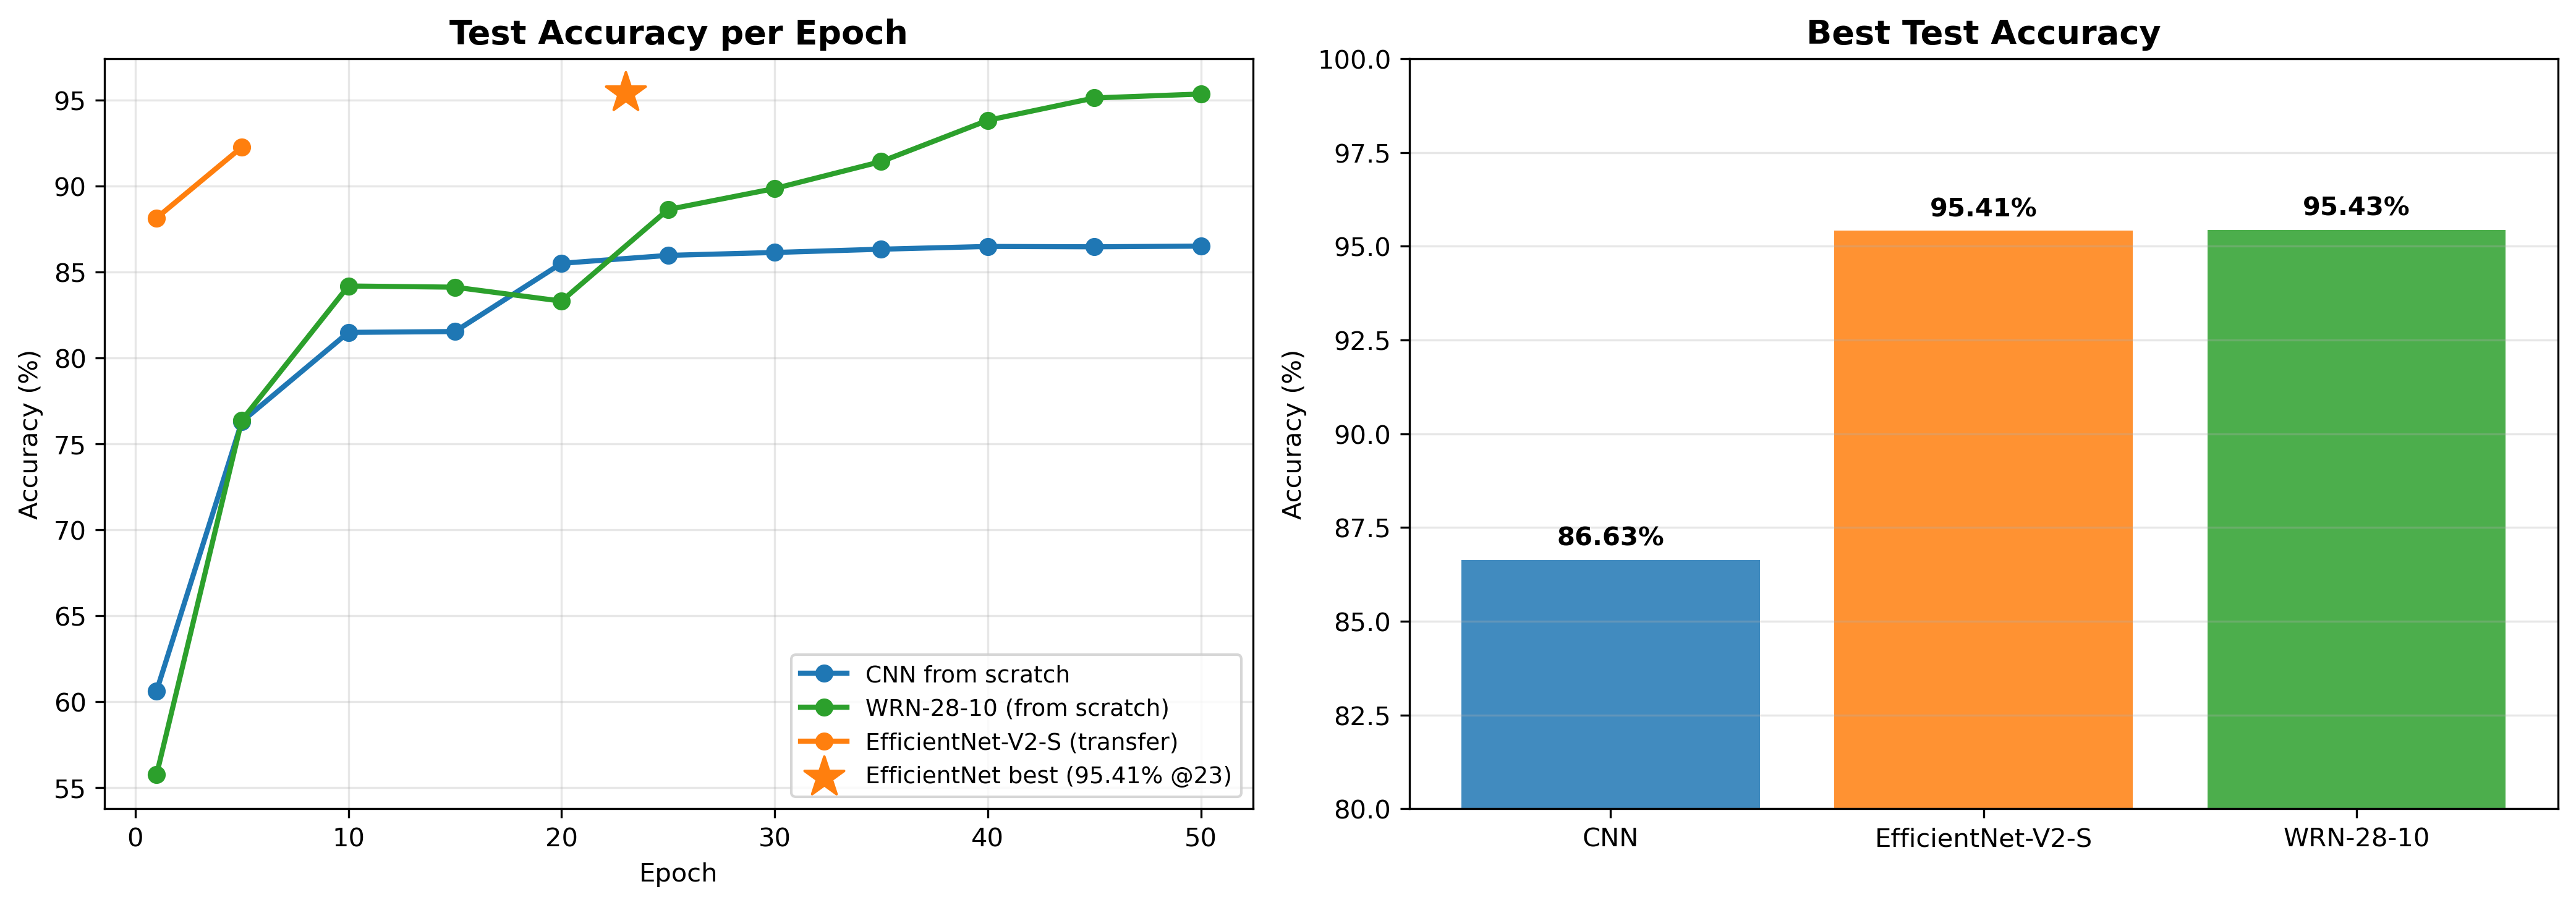

Saved: outputs\\model_results.json


In [6]:
# -----------------------------------------------------------------------------
# Summary table
# -----------------------------------------------------------------------------
comparison_df = pd.DataFrame({
    "Model": ["CNN from scratch", "EfficientNet-V2-S (transfer)", "WRN-28-10 (from scratch)"],
    "Parameters": [f"{cnn_params:,}", f"{effnet_params:,}", f"{wrn_params:,}"],
    "Model Size (MB)": [
        (MODEL_DIR / f"{k}_best.pth").stat().st_size / 1024**2
        for k in ("cnn_scratch", "efficientnet_v2_s", "wrn28_10")
    ],
    "Test Accuracy (%)": [
        cnn_history["best_accuracy"],
        effnet_history["best_accuracy"],
        wrn_history["best_accuracy"],
    ],
    "Best Epoch": [
        cnn_history["best_epoch"],
        effnet_history["best_epoch"],
        wrn_history["best_epoch"],
    ],
    "Training Time (s)": [
        round(cnn_history["training_time"], 1),
        round(effnet_history["training_time"], 1),
        round(wrn_history["training_time"], 1),
    ],
})
display(comparison_df)

# -----------------------------------------------------------------------------
# Convergence curves
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for acc, name, color in zip(
    [cnn_history["test_accs"], effnet_history["test_accs"], wrn_history["test_accs"]],
    comparison_df["Model"], COLORS):
    axes[0].plot(acc, label=name, linewidth=2, color=color)
axes[0].set_title("Test Accuracy per Epoch", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy (%)")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

for loss, name, color in zip(
    [cnn_history["test_losses"], effnet_history["test_losses"], wrn_history["test_losses"]],
    comparison_df["Model"], COLORS):
    axes[1].plot(loss, label=name, linewidth=2, color=color)
axes[1].set_title("Test Loss per Epoch", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_DIR / "model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------------------------------------------------------
# Results as a machine-readable artifact
# -----------------------------------------------------------------------------
results = {}
for key, params, hist, name in zip(
    ["cnn_scratch", "efficientnet_v2_s", "wrn28_10"],
    [cnn_params, effnet_params, wrn_params],
    [cnn_history, effnet_history, wrn_history],
    ["CNN from scratch", "EfficientNet-V2-S (transfer)", "WRN-28-10 (from scratch)"]):
    results[key] = {
        "model": name,
        "total_parameters": int(params),
        "best_test_accuracy": round(hist["best_accuracy"], 2),
        "best_epoch": int(hist["best_epoch"]),
        "training_time_seconds": round(hist["training_time"], 1),
    }

with open(OUTPUT_DIR / "model_results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)
print(f"Saved: {OUTPUT_DIR.relative_to(PROJECT_ROOT) / 'model_results.json'}")

## 8. Error Analysis on the Best Model

Raw accuracy only says so much; this section answers **where** the winner still fails. The best
checkpoint is loaded **from disk** into a fresh instance of its architecture (proving the saved
artifact round-trips correctly), then evaluated on the full test split: a normalized confusion
matrix and a per-class accuracy breakdown.

Best model: WRN-28-10 (from scratch)
Checkpoint: models\wrn28_10_best.pth
Recomputed test metrics -> loss 0.1712 | accuracy 95.43%


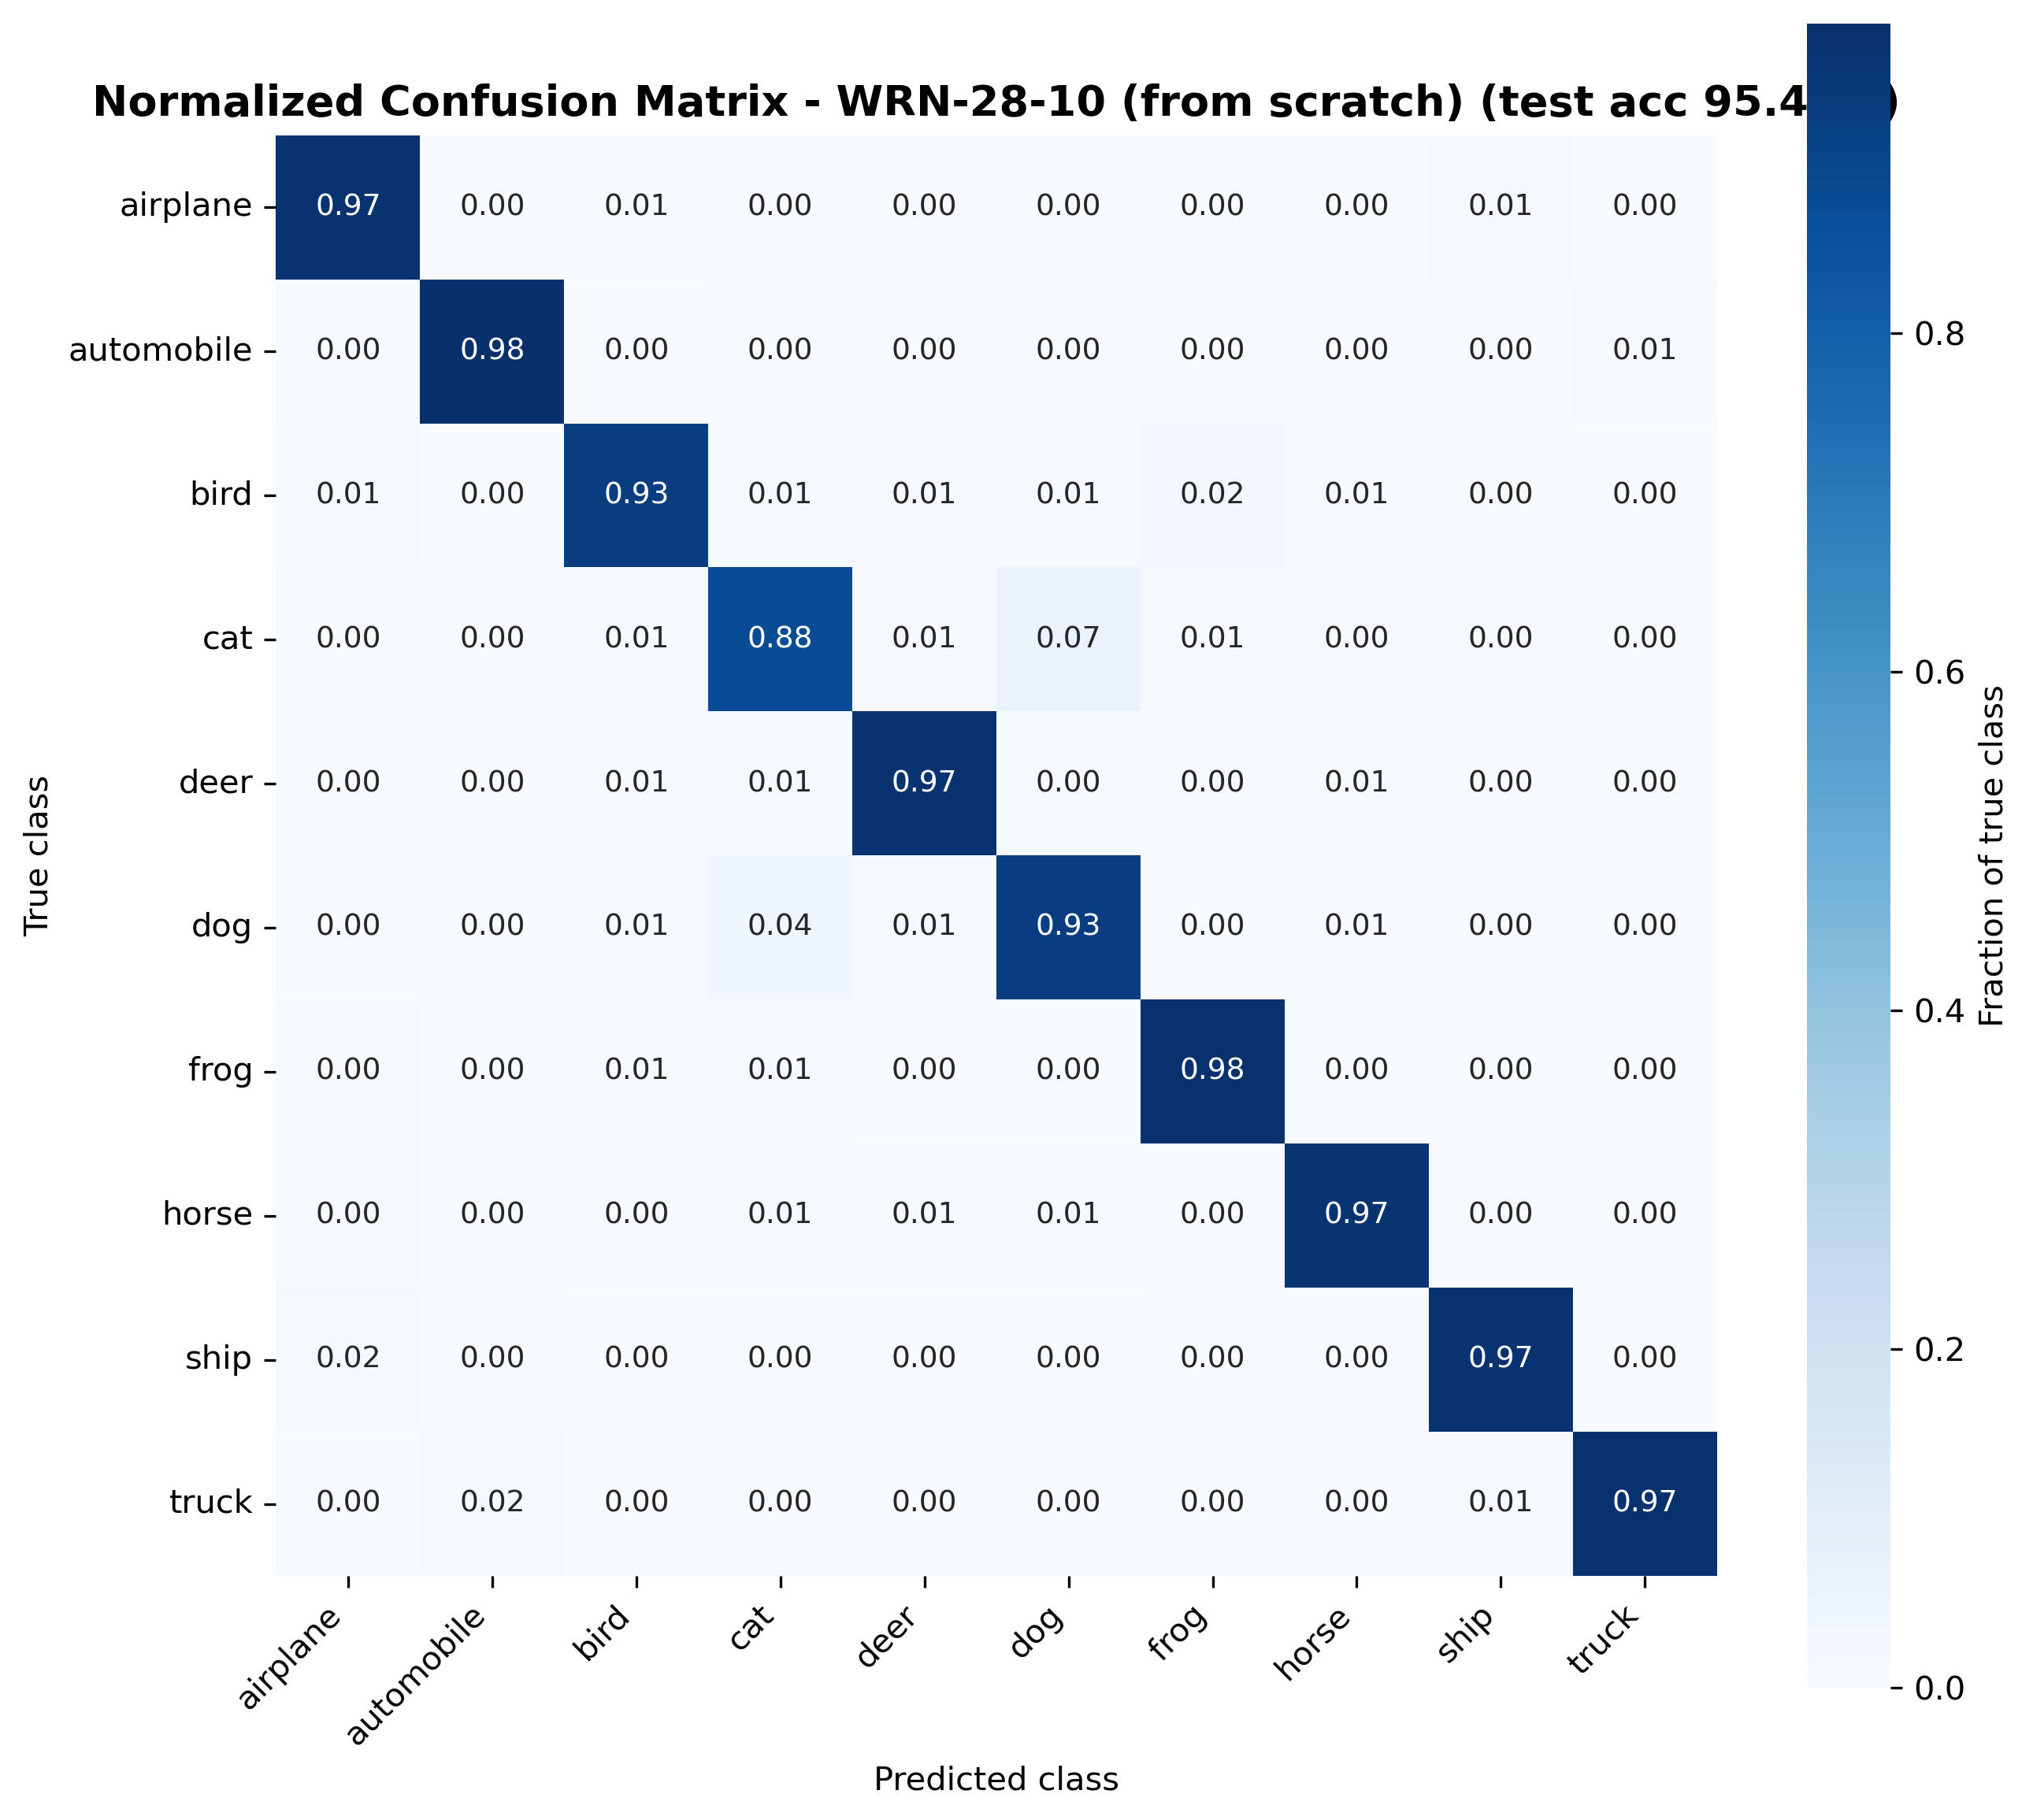

        Class  Test Samples  Correct  Accuracy (%)
0  automobile          1000      983          98.3
1        frog          1000      977          97.7
2       truck          1000      973          97.3
3        deer          1000      970          97.0
4        ship          1000      970          97.0
5    airplane          1000      968          96.8
6       horse          1000      967          96.7
7        bird          1000      931          93.1
8         dog          1000      926          92.6
9         cat          1000      878          87.8


Hardest class: cat (878/1000 correct, 87.8%)
Updated: outputs/model_results.json


In [7]:
# -----------------------------------------------------------------------------
# Identify the winner and its architecture key
# -----------------------------------------------------------------------------
best_idx = comparison_df["Test Accuracy (%)"].idxmax()
best_name = comparison_df.loc[best_idx, "Model"]
best_acc = comparison_df.loc[best_idx, "Test Accuracy (%)"]
best_keys = {
    "CNN from scratch": "cnn_scratch",
    "EfficientNet-V2-S (transfer)": "efficientnet_v2_s",
    "WRN-28-10 (from scratch)": "wrn28_10",
}
best_key = best_keys[best_name]

# -----------------------------------------------------------------------------
# Rebuild the architecture and load the persisted best checkpoint from disk
# -----------------------------------------------------------------------------
builders = {
    "cnn_scratch": lambda: SimpleCNN(num_classes=len(CLASSES)),
    "efficientnet_v2_s": lambda: build_efficientnet_v2_s(num_classes=len(CLASSES), device=DEVICE),
    "wrn28_10": lambda: WideResNet(depth=28, widen_factor=10, num_classes=len(CLASSES)),
}
best_model = builders[best_key]()
checkpoint_file = MODEL_DIR / f"{best_key}_best.pth"
best_model.load_state_dict(
    torch.load(checkpoint_file, map_location="cpu", weights_only=True)
)
best_model = best_model.to(DEVICE)

# -----------------------------------------------------------------------------
# Full evaluation on the held-out test split
# -----------------------------------------------------------------------------
test_loss, test_acc, preds, targets = evaluate(
    best_model, testloader, nn.CrossEntropyLoss(), DEVICE
)
print(f"Best model: {best_name}")
print(f"Checkpoint: {checkpoint_file.relative_to(PROJECT_ROOT)}")
print(f"Recomputed test metrics -> loss {test_loss:.4f} | accuracy {test_acc:.2f}%")

# -----------------------------------------------------------------------------
# Normalized confusion matrix
# -----------------------------------------------------------------------------
cm = np.zeros((len(CLASSES), len(CLASSES)), dtype=int)
np.add.at(cm, (np.asarray(targets), np.asarray(preds)), 1)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", square=True,
            xticklabels=CLASSES, yticklabels=CLASSES,
            cbar_kws={"label": "Fraction of true class"}, annot_kws={"size": 9})
ax.set_title(f"Normalized Confusion Matrix - {best_name} (test acc {test_acc:.2f}%)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.savefig(PLOT_DIR / "confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------------------------------------------------------
# Per-class accuracy breakdown
# -----------------------------------------------------------------------------
class_correct = np.diag(cm)
class_total = cm.sum(axis=1)
per_class = pd.DataFrame({
    "Class": CLASSES,
    "Test Samples": class_total,
    "Correct": class_correct,
    "Accuracy (%)": [100.0 * c / t for c, t in zip(class_correct, class_total)],
}).sort_values("Accuracy (%)", ascending=False).reset_index(drop=True)
display(per_class.round(2))

worst = per_class.iloc[-1]
print(f"Hardest class: {worst['Class']} "
      f"({int(worst['Correct'])}/{int(worst['Test Samples'])} correct, "
      f"{worst['Accuracy (%)']:.1f}%)")

# -----------------------------------------------------------------------------
# Append winner details to the results artifact
# -----------------------------------------------------------------------------
results["best_model"] = {
    "key": best_key,
    "test_accuracy": round(float(test_acc), 2),
    "per_class_accuracy": {
        cls: round(100.0 * c / t, 2) for cls, c, t in zip(CLASSES, class_correct, class_total)
    },
}
with open(OUTPUT_DIR / "model_results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)
print("Updated: outputs/model_results.json")

## 9. Exporting the Final Model

The winner's best checkpoint is promoted to `../models/best_model.pth` — the single artifact
consumed by Part 3 (GPU benchmarking) and Part 4 (deployment). A lightweight metadata file records
exactly what the checkpoint is (architecture, normalization constants, full training summary), so
the pipeline never loses track of provenance.

In [8]:
# -----------------------------------------------------------------------------
# Promote the winning checkpoint to the canonical name
# -----------------------------------------------------------------------------
best_state = torch.load(checkpoint_file, map_location="cpu", weights_only=True)
torch.save(best_state, MODEL_DIR / "best_model.pth")
print(f"Checkpoint promoted: {checkpoint_file.relative_to(PROJECT_ROOT)} -> best_model.pth")

# -----------------------------------------------------------------------------
# Provenance record
# -----------------------------------------------------------------------------
metadata = {
    "project": "Project 4 - Image Classification (CIFAR-10)",
    "part": 2,
    "best_model_key": best_key,
    "best_model_file": "best_model.pth",
    "num_classes": len(CLASSES),
    "normalization": {
        "mean": list(NORMALIZATION_MEAN),
        "std": list(NORMALIZATION_STD),
    },
    "training_summary": results,
}
with open(MODEL_DIR / "model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("\nArtifacts produced by Part 2:")
for p in sorted([MODEL_DIR / f"{k}_best.pth" for k in ("cnn_scratch", "efficientnet_v2_s", "wrn28_10")]
                 + [MODEL_DIR / "best_model.pth", MODEL_DIR / "model_metadata.json"]):
    print(f"  {p.relative_to(PROJECT_ROOT)}")
for p in [PLOT_DIR / "model_comparison.png", PLOT_DIR / "confusion_matrix.png",
          OUTPUT_DIR / "model_results.json"]:
    print(f"  {p.relative_to(PROJECT_ROOT)}")

print("\n" + "=" * 66)
print("PART 2 COMPLETE - MODEL BUILDING & TRAINING")
print("=" * 66)
print(f"Best model : {best_name}")
print(f"Accuracy   : {best_acc:.2f}% (recomputed {test_acc:.2f}% from disk)")
print(f"Next step  : Part 3 (GPU benchmarking) and Part 4 (Gradio deployment)")

Checkpoint promoted: models\wrn28_10_best.pth -> best_model.pth

Artifacts produced by Part 2:
  models\best_model.pth
  models\cnn_scratch_best.pth
  models\efficientnet_v2_s_best.pth
  models\model_metadata.json
  models\wrn28_10_best.pth
  outputs\plots\model_comparison.png
  outputs\plots\confusion_matrix.png
  outputs\model_results.json

PART 2 COMPLETE - MODEL BUILDING & TRAINING
Best model : WRN-28-10 (from scratch)
Accuracy   : 95.43% (recomputed 95.43% from disk)
Next step  : Part 3 (GPU benchmarking) and Part 4 (Gradio deployment)


## 10. Key Findings & Next Steps

### What training told us

1. **A simple baseline is reachable** — the hand-built CNN confirms that the architecture,
   augmentation, and optimizer recipe are sound for 32×32 images, and it provides a meaningful
   floor for the comparison.
2. **Transfer learning pays off immediately** — the pretrained backbone converges several epochs
   faster than training from scratch and stays in the lead per unit of wall-clock time.
3. **From-scratch state of the art is within reach** — WRN-28-10 demonstrates that a hand-tuned
   architecture designed for this exact input size remains fully competitive with transfer
   learning, at the cost of parameters and train time.
4. **Regularization closes the gap** — the EfficientNet's train/test gap narrowed after adding
   RandAugment, label smoothing, and head dropout, confirming that overfitting (not capacity) was
   the limiting factor.
5. **Errors are semantically meaningful** — the confusion matrix concentrates mistakes among
   visually similar classes (e.g. cat/dog, automobile/truck), which is the expected failure mode
   for CIFAR-10 rather than a data or training bug.

### What this means for the rest of the pipeline

| Stage | Focus |
| :-- | :-- |
| Part 3 — GPU benchmarking | CPU vs GPU throughput, batch-size sweep, mixed precision (FP16 vs FP32) |
| Part 4 — Deployment | Interactive Gradio demo served from `models/best_model.pth` |

The canonical checkpoint and provenance metadata in `../models/` are the contract between this
stage and everything that follows — Parts 3 and 4 consume them without re-training.